# Part 2- Accessing the data set from github to colab

In [1]:
!git clone https://github.com/patitimoner/itai2377-datasets.git
%cd itai2377-datasets
!ls

fatal: destination path 'itai2377-datasets' already exists and is not an empty directory.
/content/itai2377-datasets
BBC-Dataset-News-Classification  ITAI2377_Lab_Student_Notebook.ipynb
data				 README.md


# Part 3-Importing pandas

In [2]:
import pandas as pd

df = pd.read_csv("data/structured/Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Part 4-Understanding image Data(Computer Vison)[TensorFlow/Keras]

In [3]:
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Select only 10 images per class

# ✨ TIP: How can you filter specific images based on class labels?

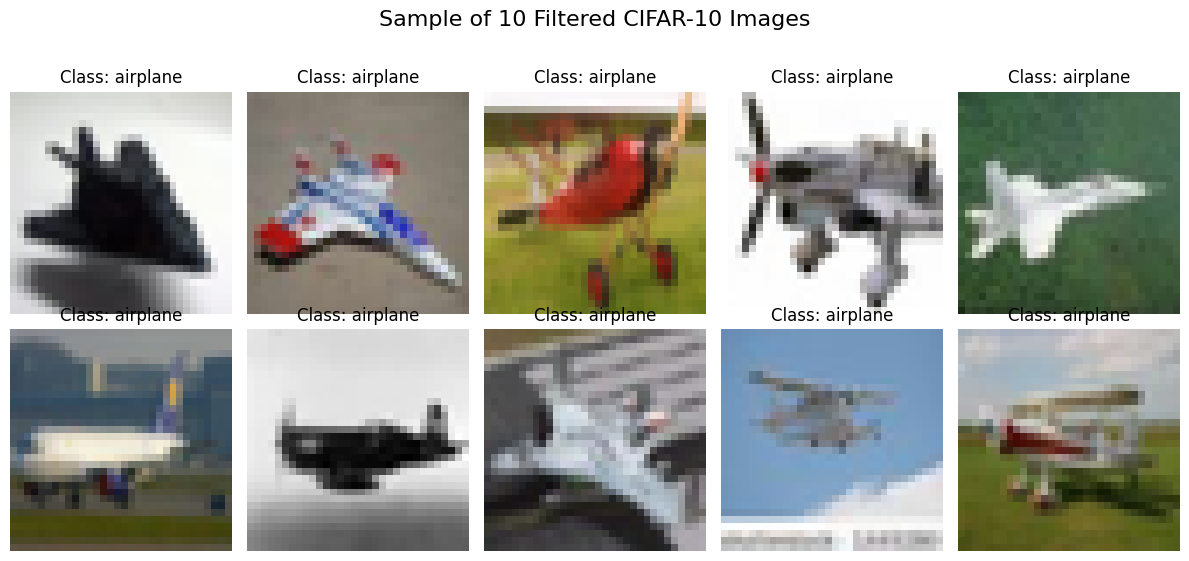

In [4]:
import matplotlib.pyplot as plt
import numpy as np # Added import for numpy

# Filter the CIFAR-10 data to create x_train_filtered and y_train_filtered.
# This code is moved from cell 2150421f to resolve the NameError.
# Get the number of classes from y_train
num_classes = len(np.unique(y_train))
images_per_class = 10

x_train_filtered = []
y_train_filtered = []

for class_label in range(num_classes):
    # Get indices where the label matches the current class
    class_indices = np.where(y_train == class_label)[0]

    # Select a fixed number of images (e.g., 10) for this class
    selected_indices = class_indices[:images_per_class]

    # Append the selected images and labels to the filtered lists
    x_train_filtered.append(x_train[selected_indices])
    y_train_filtered.append(y_train[selected_indices])

# Concatenate the lists to form final numpy arrays
x_train_filtered = np.concatenate(x_train_filtered, axis=0)
y_train_filtered = np.concatenate(y_train_filtered, axis=0)

# Define CIFAR-10 class names (important for labeling plots)
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Let's visualize a few of the filtered images
num_images_to_display = 10

plt.figure(figsize=(12, 6))
for i in range(num_images_to_display):
    plt.subplot(2, 5, i + 1) # Arrange in 2 rows, 5 columns
    plt.imshow(x_train_filtered[i])
    # The y_train_filtered is (100, 1), so we access the label like y_train_filtered[i][0]
    plt.title(f"Class: {cifar10_class_names[y_train_filtered[i][0]]}")
    plt.axis('off')
plt.suptitle(f"Sample of {num_images_to_display} Filtered CIFAR-10 Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

To filter CIFAR-10 images by class label, we can iterate through each unique class, find the indices corresponding to that class, and then select a specific number of images and their labels.

In [5]:
import numpy as np

# Get the number of classes from y_train
num_classes = len(np.unique(y_train))
images_per_class = 10

x_train_filtered = []
y_train_filtered = []

for class_label in range(num_classes):
    # Get indices where the label matches the current class
    class_indices = np.where(y_train == class_label)[0]

    # Select a fixed number of images (e.g., 10) for this class
    selected_indices = class_indices[:images_per_class]

    # Append the selected images and labels to the filtered lists
    x_train_filtered.append(x_train[selected_indices])
    y_train_filtered.append(y_train[selected_indices])

# Concatenate the lists to form final numpy arrays
x_train_filtered = np.concatenate(x_train_filtered, axis=0)
y_train_filtered = np.concatenate(y_train_filtered, axis=0)

print(f"Shape of filtered x_train: {x_train_filtered.shape}")
print(f"Shape of filtered y_train: {y_train_filtered.shape}")

Shape of filtered x_train: (100, 32, 32, 3)
Shape of filtered y_train: (100, 1)


# Part 4-Understanding image Data(Computer Vison)[PyTorch]

In [6]:
import torchvision
import torchvision.transforms as transforms

# Load CIFAR-10 dataset from TorchVision
dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transforms.ToTensor())

# Extract a subset of 10 images per class

# ✨ TIP: What function in PyTorch DataLoader allows sampling specific indices?

In [7]:
import torch
import numpy as np # Import numpy for array operations on targets
from torch.utils.data import DataLoader, SubsetRandomSampler

# Assuming the 'dataset' from the previous cell (jLHmOahnLHA_) is now loaded and available

# --- Logic to select 10 images per class for PyTorch dataset (similar to TensorFlow/Keras) ---
num_classes = 10 # CIFAR-10 has 10 classes
images_per_class = 10

# Get the labels (targets) from the dataset.targets attribute
targets = np.array(dataset.targets) # Convert to numpy for easier indexing

specific_indices = []
for class_label in range(num_classes):
    class_indices = np.where(targets == class_label)[0]
    selected_indices_for_class = class_indices[:images_per_class]
    specific_indices.extend(selected_indices_for_class)

# --- Rest of the DataLoader setup ---
print(f"Original dataset size: {len(dataset)}")
print(f"Number of specific indices to sample: {len(specific_indices)}")

# Create a sampler from the specific indices
sampler = SubsetRandomSampler(specific_indices)

# Create a DataLoader using the sampler
batch_size = 4
subset_dataloader = DataLoader(dataset, batch_size=batch_size, sampler=sampler)

# Iterate through the DataLoader to see the sampled data
print(f"\nIterating through DataLoader (batch_size={batch_size}):")
for i, (images, labels) in enumerate(subset_dataloader):
    print(f"Batch {i+1}: images shape={images.shape}, labels shape={labels.shape}")
    if i >= 2: # Print only first few batches for brevity
        break

# Example of getting all items sampled by the dataloader
all_sampled_indices = []
for index in sampler:
    all_sampled_indices.append(index)

print(f"\nAll sampled indices (from sampler): {sorted(all_sampled_indices)}")

Original dataset size: 50000
Number of specific indices to sample: 100

Iterating through DataLoader (batch_size=4):
Batch 1: images shape=torch.Size([4, 3, 32, 32]), labels shape=torch.Size([4])
Batch 2: images shape=torch.Size([4, 3, 32, 32]), labels shape=torch.Size([4])
Batch 3: images shape=torch.Size([4, 3, 32, 32]), labels shape=torch.Size([4])

All sampled indices (from sampler): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np

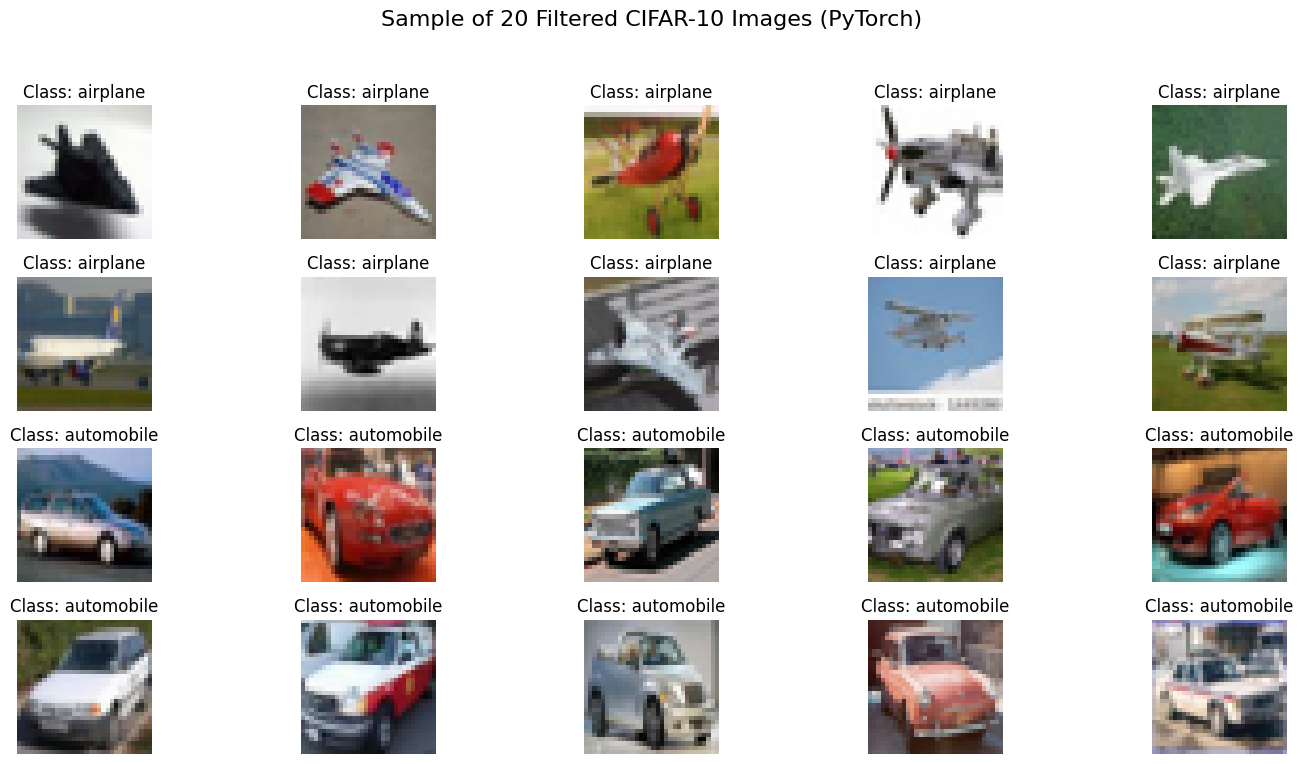

In [8]:
import matplotlib.pyplot as plt

# Ensure cifar10_class_names is available from a previous cell
# If not, you might need to define it here:
cifar10_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create a figure to display the sampled images
plt.figure(figsize=(15, 8))

# Iterate through the specific indices and plot the images
# We'll display up to 20 images to keep the plot manageable
num_images_to_display = min(len(specific_indices), 20)

for i in range(num_images_to_display):
    idx = specific_indices[i]
    image, label = dataset[idx]

    # PyTorch images are C, H, W; matplotlib expects H, W, C
    # Also, ToTensor() scales to [0, 1], which imshow can handle
    image_display = image.permute(1, 2, 0)

    plt.subplot(4, 5, i + 1) # Arrange in 4 rows, 5 columns
    plt.imshow(image_display)
    plt.title(f"Class: {cifar10_class_names[label]}")
    plt.axis('off')

plt.suptitle(f"Sample of {num_images_to_display} Filtered CIFAR-10 Images (PyTorch)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Part 5: Understanding Text Data (Natural Language Processing)

In [9]:
#hint: Open and analyze a sample BBC News article from GitHub (data/text/bbc_news/) or Kaggle alternative.

#python
#CopyEdit
# Load and display a sample news article
# ✨ TIP: What Python function allows you to read a file?

#👉 Conceptual Question:

Why do AI models struggle to understand sarcasm and context in text processing?

  - AI models struggle to understand sarcasm and context primarily because these linguistic nuances rely heavily on non-textual cues, shared human experience, and complex cognitive interpretation. Sarcasm, for instance, often involves saying the opposite of what is meant, requiring an understanding of tone, facial expressions (in spoken language), or subtle textual indicators that are hard for models to discern purely from words. Context, both situational and cultural, provides the framework for interpreting meaning, and current AI models often lack the broad, real-world knowledge and common sense reasoning that humans use to make these connections. Furthermore, the limited and often explicit nature of training data means models learn patterns without truly 'understanding' the underlying human intentions and emotions.

This part i am focusing in calling the respos from github, and  presenting an article

In [10]:
!git clone https://github.com/suraj-deshmukh/BBC-Dataset-News-Classification.git
%cd BBC-Dataset-News-Classification
!ls

fatal: destination path 'BBC-Dataset-News-Classification' already exists and is not an empty directory.
/content/itai2377-datasets/BBC-Dataset-News-Classification
dataset  model	README.md


In [11]:
import pandas as pd

# Load the CSV file (update path to where you saved it)
df = pd.read_csv("/content/BBC-Dataset-News-Classification/dataset/dataset.csv", encoding='latin1')  # Updated path and added encoding

# Show first few articles
print(df.head())

# Display a single sample
sample_article = df.loc[0, "news"]
sample_label   = df.loc[0, "type"]

print("=== Sample BBC Article ===")
print("Category:", sample_label)
print(sample_article)


                                                news      type
0  China had role in Yukos split-up\n \n China le...  business
1  Oil rebounds from weather effect\n \n Oil pric...  business
2  Indonesia 'declines debt freeze'\n \n Indonesi...  business
3  $1m payoff for former Shell boss\n \n Shell is...  business
4  US bank in $515m SEC settlement\n \n Five Bank...  business
=== Sample BBC Article ===
Category: business
China had role in Yukos split-up
 
 China lent Russia $6bn (Â£3.2bn) to help the Russian government renationalise the key Yuganskneftegas unit of oil group Yukos, it has been revealed.
 
 The Kremlin said on Tuesday that the $6bn which Russian state bank VEB lent state-owned Rosneft to help buy Yugansk in turn came from Chinese banks. The revelation came as the Russian government said Rosneft had signed a long-term oil supply deal with China. The deal sees Rosneft receive $6bn in credits from China's CNPC.
 
 According to Russian newspaper Vedomosti, these credits would

#🧠 Discussion Questions (Answer in Markdown Cells)

1. How does AI process structured, image, and text data differently?

  - AI processes structured data through tabular models, analyzing rows and columns for patterns and predictions. For image data, Convolutional Neural Networks (CNNs) are employed to extract visual features from pixels. Text data utilizes Natural Language Processing (NLP) techniques like Transformers to understand context and meaning from sequences of words.

2. What real-world AI applications combine multiple types of data (structured, image, text)?

  - Many advanced AI applications, such as autonomous vehicles, integrate image data for perception, structured data for sensor readings, and text for navigation. Medical diagnosis systems combine image scans, structured patient records, and textual doctor's notes for comprehensive insights. E-commerce platforms blend product images, textual descriptions and reviews, and structured purchase history to provide personalized recommendations.

3. Imagine you're building an AI personal assistant. What type of data would it need?

  - An AI personal assistant would primarily need text data to understand commands, generate responses, and manage information like calendars or emails. It would also rely heavily on structured data for settings, contact information, and location-based services. Audio data is crucial for speech recognition and generating voice replies, while image data could enhance features on devices with displays.

#📌 Submission Guidelines
Your notebook must be structured properly:

Markdown cells for explanations & questions
Code cells for implementations
Each task in a separate cell
Save your file as:
CopyEdit
L02_Your_Name_ITAI_2377.ipynb
Submit your .ipynb notebook as a PDF on Canvas.

#🚨 ⚠️ Important:

Messy, unstructured notebooks will lose points.
Not separating tasks into distinct code & markdown cells will affect your grade.

#💡 Takeaway: AI Needs the Right Data

AI is only as good as the data it is trained on. Structured, image, and text data each require different approaches. Understanding these fundamentals is essential for building AI systems that can see, read, and analyze the world around them. 🚀